# Lane 1: Prompt Chaining

Owner: Jackson Kenyon. Development notebook; finished cells are copied into `notebook.ipynb` section 1 at assembly. See `docs/` and `setup.md`.

In [8]:
import sys
sys.path.insert(0, "..")  # this notebook lives in dev/; make src/ importable

import importlib
from src import llm, tools
#importlib.reload(src.llm)
from src.llm import chat
from src.llm import handoff


Ingest news, preprocess, classify, extract, summarize. Each stage uses the preceding stage's output.

**Contract:** `run_chain(symbol) -> {"Symbol": str, "articles": list[dict], "summary": str}`. The summary is one paragraph synthesized from all labeled articles.

**Demonstration:** run on AAPL from the cache and display the symbol and its combined news summary.

In [9]:
def ingest(symbol):
    # Stage 1: the plumbing does the fetching; this returns the cached articles.
    return tools.get_news(symbol)



def preprocess(articles: list[dict], nlp, max_tokens: int = 300) -> list[dict]:
    # Stage 2: no LLM. Deduplicate, strip, truncate. spaCy or plain Python.
    seen_titles = set()
    preprocessed_articles = []
    for article in articles:
        title=(article.get("title") or "").strip()
        summary=(article.get("summary") or "").strip()

        if not title or title in seen_titles:
            continue
        seen_titles.add(title)

        doc=nlp(summary if summary else title)

        tokens=[token.text for token in doc if not token.is_space]
        token_summary = doc[:max_tokens].text.strip()

        preprocessed_articles.append(
            {
                "title": title,
                "summary": token_summary,
                "publisher": article.get("publisher"),
                "published": article.get("published"),
                "url": article.get("url"),
            }
        )

    return preprocessed_articles

class _ClassificationValidationError(ValueError):
    pass


def classify(article: dict, symbol: str) -> dict:
    sentiment=["negative","neutral","positive"]
    topic=["earnings","news","market","other"]
    # Stage 3: one chat(..., json_mode=True) call per article -> {"sentiment", "topic"}.
    
    System=(
        "You are a financial news analyst. Classify the article using its title, summary, and company symbol.\n"
        "The symbol identifies the company the article must be about to count as relevant.\n"
        "Choose the topic that best describes the article's dominant subject, even if it touches multiple areas:\n"
        "- earnings: reported quarterly or annual results, revenue, EPS, margins, earnings growth, financial guidance, or an earnings call.\n"
        "- market: stock-price performance, valuation, trading activity, analyst price targets, sector moves, or broader market/macro effects on the stock.\n"
        "- news: company events that are not primarily earnings or market-price analysis, such as products, leadership, regulation, litigation, partnerships, operations, or corporate announcements.\n"
        "- other: the article is not mainly about the company identified by the symbol, or is unrelated to financial markets.\n"
        "Return a JSON object with exactly two keys:\n"
        '- "sentiment": one of "positive", "negative", or "neutral"\n'
        '- "topic": one of "earnings", "news", "market", or "other"'
    )

    User=f"Symbol: {symbol}\nTitle: {article['title']}\nSummary: {article['summary']}"

    for attempt in (1, 2):
        output=chat(
            system=System,
            user=User,
            json_mode=True,
            temperature=1,
            agent="News Analyst"
        )

        try:
            if not isinstance(output, dict):
                raise _ClassificationValidationError("Classifier reply must be a JSON object.")

            normalized_output = {}
            for label_name, allowed_labels in (("sentiment", sentiment), ("topic", topic)):
                raw_label = output.get(label_name)
                if not isinstance(raw_label, str):
                    raise _ClassificationValidationError(
                        f"Invalid {label_name} label {raw_label!r}; expected one of {allowed_labels}."
                    )

                normalized_label = raw_label.strip().lower()
                if normalized_label not in allowed_labels:
                    raise _ClassificationValidationError(
                        f"Invalid {label_name} label {normalized_label!r}; expected one of {allowed_labels}."
                    )
                normalized_output[label_name] = normalized_label
        except _ClassificationValidationError as error:
            if attempt == 2:
                raise
            print(f"Classifier reply rejected ({error}); asking again.")
            User = (
                f"{User}\n\nYour previous reply was rejected: {error}\n"
                "Try again. Return exactly one JSON object with sentiment set to negative, neutral, or positive "
                "and topic set to earnings, news, market, or other."
            )
            continue

        return normalized_output


def extract(article, nlp):
    # Stage 4: entities and figures. spaCy NER (en_core_web_sm is installed) or one JSON call.
    title=article.get("title")
    summary=article.get("summary")
    title_doc=nlp(title)
    summary_doc=nlp(summary)

    title_entities = [(ent.text, ent.label_) for ent in title_doc.ents]
    summary_entities = [(ent.text, ent.label_) for ent in summary_doc.ents]

    output=[]
    output.append(title_entities)
    output.append(summary_entities)


    return output
    #raise NotImplementedError


def summarize(symbol, articles):
    # Stage 5: one chat() call over every labeled article -> one grounded paragraph.
    if not articles:
        return f"No news articles were available for {symbol}."

    article_sections = []
    for index, article in enumerate(articles, start=1):
        title = article.get("title") or "Untitled"
        summary = (article.get("summary") or "").strip() or "No summary provided."
        section = [f"{index}. {title}", f"Summary: {summary}"]
        if article.get("sentiment"):
            section.append(f"sentiment: {article['sentiment']}")
        if article.get("topic"):
            section.append(f"topic: {article['topic']}")
        if article.get("entities"):
            section.append(f"entities: {article['entities']}")
        article_sections.append("\n".join(section))

    system = (
        "You are a careful financial news summarizer. Write exactly one concise paragraph "
        "of no more than five sentences synthesizing the supplied articles about the given symbol. "
        "Use only information in the articles, distinguish reported claims from established facts, "
        "and do not add predictions or investment advice."
    )
    user = f"Symbol: {symbol}\n\nArticles:\n" + "\n\n".join(article_sections)

    return chat(
        system=system,
        user=user,
        max_tokens=500,
        temperature=1,
        agent="News Analyst",
    )


def run_chain(symbol):
    # The function the agent calls. Runs the five stages in order.
    import spacy

    # Load spaCy model (disable unnecessary pipeline components for speed)
    nlp = spacy.load("en_core_web_sm", disable=["parser"])

    fetched_articles = ingest(symbol)
    articles = preprocess(fetched_articles, nlp)
    labeled_articles = []
    dropped_count = 0

    for article in articles:
        labeled_article = article.copy()
        labeled_article.update(classify(labeled_article, symbol))
        if labeled_article["topic"] == "other":
            dropped_count += 1
            continue
        labeled_article["entities"] = extract(labeled_article, nlp)
        labeled_articles.append(labeled_article)

    print(f"Dropped {dropped_count} of {len(articles)} articles as other.")
    summary = summarize(symbol, labeled_articles)
    return {
        "symbol": symbol,
        "articles": labeled_articles,
        "summary": summary,
    }


def visualize(result: dict):
    from html import escape

    import matplotlib.pyplot as plt
    from IPython.display import HTML, display

    symbol = result.get("symbol", "Unknown")
    summary = result.get("summary") or "No summary available."
    articles = result.get("articles", [])
    table_rows = []

    for article in articles:
        entities = [
            f"{entity_text} ({entity_label})"
            for entity_group in article.get("entities", [])
            for entity_text, entity_label in entity_group
        ]
        values = [
            article.get("title") or "Untitled",
            article.get("sentiment") or "Unlabeled",
            article.get("topic") or "Uncategorized",
            ", ".join(entities) or "None",
        ]
        cells = "".join(f"<td>{escape(str(value))}</td>" for value in values)
        table_rows.append(f"<tr>{cells}</tr>")

    if not table_rows:
        table_rows.append('<tr><td colspan="4">No articles available.</td></tr>')

    table_html = (
        f"<h3>{escape(str(symbol))} summary</h3>"
        f"<p class='chain-summary'>{escape(str(summary))}</p>"
        f"<h3>{escape(str(symbol))} news by article</h3>"
        "<style>"
        ".chain-summary{line-height:1.5;margin:0 0 14px}"
        ".chain-table{border-collapse:collapse;width:100%;table-layout:fixed;font-size:12px}"
        ".chain-table th,.chain-table td{border:1px solid #c9d1d9;padding:6px;"
        "text-align:left;vertical-align:top;overflow-wrap:anywhere}"
        ".chain-table th{background:#eef2f5}"
        ".chain-table tr:nth-child(even){background:#f7f9fa}"
        "</style>"
        '<table class="chain-table"><thead><tr>'
        "<th style='width:36%'>Article</th><th style='width:14%'>Sentiment</th>"
        "<th style='width:14%'>Topic</th><th style='width:36%'>Entities</th>"
        "</tr></thead><tbody>"
        + "".join(table_rows)
        + "</tbody></table>"
    )
    display(HTML(table_html))

    sentiment_labels = ["negative", "neutral", "positive"]
    sentiment_counts = [
        sum(
            1
            for article in articles
            if str(article.get("sentiment", "")).lower() == sentiment
        )
        for sentiment in sentiment_labels
    ]
    topic_labels = ["earnings", "news", "market"]
    topic_counts = [
        sum(
            1
            for article in articles
            if str(article.get("topic", "")).lower() == topic
        )
        for topic in topic_labels
    ]

    figure, (sentiment_axis, topic_axis) = plt.subplots(1, 2, figsize=(12, 4))
    sentiment_bars = sentiment_axis.bar(
        sentiment_labels,
        sentiment_counts,
        color=["#d95f59", "#89939d", "#319b79"],
        width=0.62,
    )
    sentiment_axis.bar_label(sentiment_bars, padding=3)
    sentiment_axis.set_title(f"Sentiment distribution for {symbol}")
    sentiment_axis.set_xlabel("Sentiment")
    sentiment_axis.set_ylabel("Number of articles")
    sentiment_axis.set_ylim(0, max(sentiment_counts, default=0) + 1)

    topic_bars = topic_axis.bar(
        topic_labels,
        topic_counts,
        color=["#4e79a7", "#f28e2b", "#59a14f"],
        width=0.62,
    )
    topic_axis.bar_label(topic_bars, padding=3)
    topic_axis.set_title(f"Topic distribution for {symbol}")
    topic_axis.set_xlabel("Topic")
    topic_axis.set_ylabel("Number of articles")
    topic_axis.set_ylim(0, max(topic_counts, default=0) + 1)

    for chart_axis in (sentiment_axis, topic_axis):
        chart_axis.set_axisbelow(True)
        chart_axis.yaxis.grid(True, color="#dfe3e6", linewidth=0.8)
        chart_axis.spines["top"].set_visible(False)
        chart_axis.spines["right"].set_visible(False)

    figure.tight_layout()
    plt.show()

## Demonstration

Run the function on cached data and produce the table and figure described above. Keep printed output narrow enough for a PDF page.

Put demo code inside the `if __name__ == "__main__":` block below. It runs normally in this notebook, but not when another lane imports this notebook's `.py` export, so importing your functions never re-runs your LLM calls and plots.

Dropped 7 of 10 articles as other.


Article,Sentiment,Topic,Entities
Nvidia Stock And 2 US AI Infrastructure Plays Tied To Federal Defense Spending,positive,news,"Nvidia Stock (ORG), 2 (CARDINAL), Washington (GPE), AI (ORG), an ""AI Force (ORG), AI (GPE), 3 (CARDINAL), US (GPE), AI (ORG)"
Applied Materials vs. Nvidia: Which Tech Stock Is a Better Buy in 2026?,neutral,market,"Applied Materials (ORG), Nvidia (PERSON), 2026 (DATE), Nvidia (GPE), 55.6% (PERCENT), Applied Materials' (ORG), 24.7% (PERCENT)"
Nvidia (NVDA) Forms Alliance To Build A Power Flexible AI Data Center,positive,news,"Nvidia (GPE), NVDA (ORG), NasdaqGS (PERSON), NVDA (ORG), Google (ORG), Emerald AI (PERSON), the AI Energy Management Alliance (ORG), AI (GPE), first (ORDINAL), AI (ORG), AEMA (ORG), AI (GPE), AEMA (ORG)"


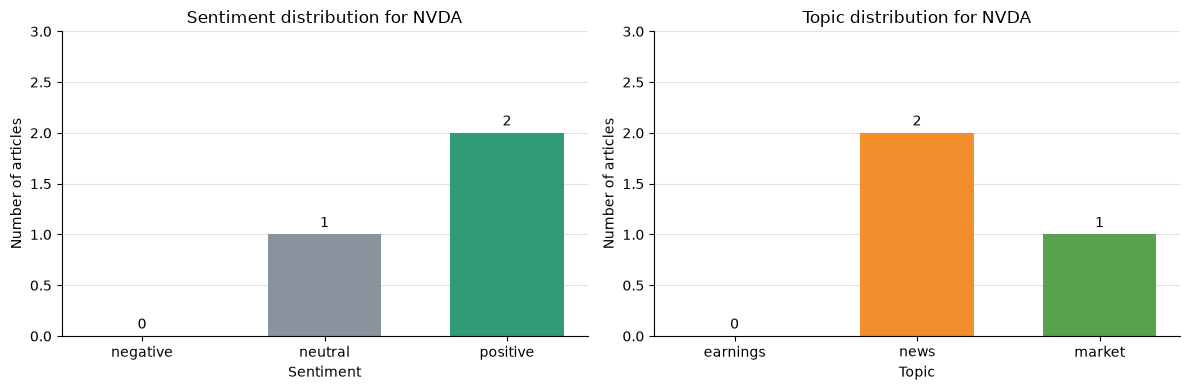

In [10]:
if __name__ == "__main__":
    result = run_chain("NVDA")
    visualize(result)